# 01 EDA: まずデータを確認する(S6E10 Predicting Airline Satisfaction)

目的: 特徴量を考える前に、データの形・target・欠損・train/test の違いを押さえる。

- 1セル = 1つの問い。各問いの下の「見えたこと」は自分で書く(事実 / 比較 / 理由の仮説 / 次の行動)
- 図は `eda_figs/` に保存される

## 準備: 読み込み

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 200)

DATA = Path("/kaggle/input/playground-series-s6e10")
ID, TARGET = "id", "satisfaction"
TRAIN_C, TEST_C = "#2a78d6", "#eb6834"  # train=青, test=橙(全図で共通)。図中の文字は英語(Kaggleに日本語フォントがないため)
FALSE_C, TRUE_C = "#e87ba4", "#1baf7a"  # target: False=マゼンタ, True=アクア(train/testの青・橙と区別)
FIG = Path("eda_figs")
FIG.mkdir(exist_ok=True)

train = pd.read_csv(DATA / "train.csv")
test = pd.read_csv(DATA / "test.csv")
print([p.name for p in DATA.iterdir()])  # 配布ファイル一覧(original データの有無も確認)

['train.csv', 'test.csv', 'sample_submission.csv']


## Q1. データの大きさと列は? train と test で列は揃っているか?
なぜ見るか: 行数で使える手法・CV の重さが決まる。列の差が target 以外にあれば前処理で揃える必要がある。

予想: test は train に比べて target 列がないだけ。

In [2]:
print("train.shape:", train.shape)
print("test.shape:", test.shape)
print("train にだけある列:", sorted(set(train.columns) - set(test.columns)))
print("test にだけある列:", sorted(set(test.columns) - set(train.columns)))
# 列が多くて横に切れるので .T で行と列を入れ替えて見る(列=縦、0〜4=先頭5行)
display(train.head().T)
display(test.head().T)

train.shape: (699635, 23)
test.shape: (299844, 22)
train にだけある列: ['satisfaction']
test にだけある列: []


,0,1,2,3,4
id,0,1,2,3,4
Age,36,56,31,10,23
Flight Distance,694,651,1371,1616,481
Inflight wifi service,4,5,3,3,3
Departure/Arrival time convenient,4,5,4,5,4
Ease of Online booking,4,5,2,3,3
Gate location,3,5,5,3,4
Food and drink,1,5,3,3,5
Online boarding,4,4,3,3,3
Seat comfort,1,4,3,3,5


,0,1,2,3,4
id,699635,699636,699637,699638,699639
Age,25,36,45,45,34
Flight Distance,1197,829,472,762,594
Inflight wifi service,4,5,4,2,1
Departure/Arrival time convenient,4,5,5,2,2
Ease of Online booking,4,5,5,2,1
Gate location,2,5,5,5,1
Food and drink,3,5,4,3,2
Online boarding,4,4,4,2,1
Seat comfort,3,5,4,3,2


**見えたこと**(ここに書く)
- 事実:
- 比較:
- 理由の仮説:
- 次の行動:

## Q2. 各列の型とユニーク数は?(どれがカテゴリ列か)
なぜ見るか: カテゴリ列の扱い(category 型 / エンコード)と、数値に見えて実は段階評価の列を見分けるため。

予想: 文字列のカテゴリ列が数本、0〜5 の満足度評価の整数列が多数、遅延や距離などの連続値が少し。

In [3]:
cols = [c for c in test.columns if c != ID]
info = pd.DataFrame({
    "dtype": train[cols].dtypes.astype(str),
    "nunique_train": train[cols].nunique(),
    "nunique_test": test[cols].nunique(),
})
info["diff(test-train)"] = info["nunique_test"] - info["nunique_train"]
info["only_test"] = [len(set(test[c].dropna()) - set(train[c].dropna())) for c in cols]    # testにだけある値の数
info["only_train"] = [len(set(train[c].dropna()) - set(test[c].dropna())) for c in cols]   # trainにだけある値の数
info["例"] = [train[c].dropna().unique()[:6].tolist() for c in cols]
print("target の種類数:", train[TARGET].nunique())
info

target の種類数: 2


,dtype,nunique_train,nunique_test,diff(test-train),only_test,only_train,例
Age,int64,75,75,0,0,0,"[36, 56, 31, 10, 23, 34]"
Flight Distance,int64,3474,3317,-157,47,204,"[694, 651, 1371, 1616, 481, 584]"
Inflight wifi service,int64,6,6,0,0,0,"[4, 5, 3, 1, 2, 0]"
Departure/Arrival time convenient,int64,6,6,0,0,0,"[4, 5, 3, 2, 0, 1]"
Ease of Online booking,int64,6,6,0,0,0,"[4, 5, 2, 3, 1, 0]"
Gate location,int64,6,6,0,0,0,"[3, 5, 4, 2, 1, 0]"
Food and drink,int64,6,6,0,0,0,"[1, 5, 3, 4, 2, 0]"
Online boarding,int64,6,6,0,0,0,"[4, 3, 2, 1, 5, 0]"
Seat comfort,int64,6,6,0,0,0,"[1, 4, 3, 5, 2, 0]"
Inflight entertainment,int64,6,6,0,0,0,"[1, 5, 3, 4, 2, 0]"


以降は「文字列の列 + ユニーク数が10以下の数値列」をカテゴリ扱い、それ以外を連続値として見る。

In [4]:
cat_cols = [c for c in cols if train[c].dtype in ("object", "str") or train[c].nunique() <= 10]
num_cols = [c for c in cols if c not in cat_cols]
print("カテゴリ扱い:", cat_cols)
print("連続値:", num_cols)

カテゴリ扱い: ['Inflight wifi service', 'Departure/Arrival time convenient', 'Ease of Online booking', 'Gate location', 'Food and drink', 'Online boarding', 'Seat comfort', 'Inflight entertainment', 'On-board service', 'Leg room service', 'Baggage handling', 'Checkin service', 'Cleanliness', 'Gender', 'Customer Type', 'Type of Travel', 'Class']
連続値: ['Age', 'Flight Distance', 'Departure Delay in Minutes', 'Arrival Delay in Minutes']


**見えたこと**(ここに書く)
- 事実:
- 比較:
- 理由の仮説:
- 次の行動:

## Q4. 欠損はどの列にどれくらいあるか? train と test で同じか?
なぜ見るか: 欠損の扱い(そのまま LightGBM に任せる / 補完 / 欠損フラグ)を決めるため。train と test で率が違えば要注意。

,train,test
Age,0,0.0
Arrival Delay in Minutes,292,130.0
Baggage handling,0,0.0
Checkin service,0,0.0
Class,0,0.0
Cleanliness,0,0.0
Customer Type,0,0.0
Departure Delay in Minutes,0,0.0
Departure/Arrival time convenient,0,0.0
Ease of Online booking,0,0.0


                           train    test
Arrival Delay in Minutes  0.0004  0.0004


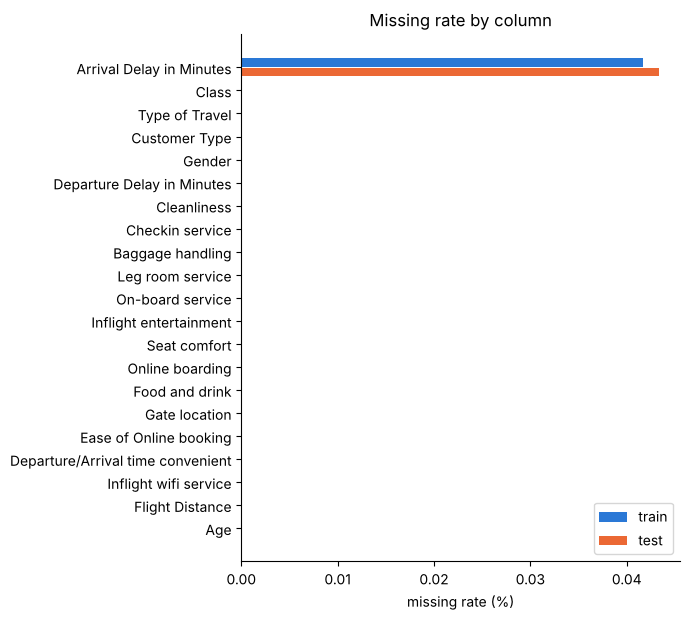

In [5]:
# 件数: test には target 列がないので、その行は NaN になる
display(pd.DataFrame({"train": train.isnull().sum(), "test": test.isnull().sum()}))

miss = pd.DataFrame({
    "train": train[cols].isna().mean(),
    "test": test[cols].isna().mean(),
})
print(miss[(miss > 0).any(axis=1)].sort_values("train", ascending=False).round(4))

m = miss.sort_values("train")
y = np.arange(len(m))
fig, ax = plt.subplots(figsize=(7, max(3, 0.3 * len(m))))
ax.barh(y + 0.2, m["train"] * 100, height=0.38, color=TRAIN_C, label="train")
ax.barh(y - 0.2, m["test"] * 100, height=0.38, color=TEST_C, label="test")
ax.set_yticks(y, m.index)
ax.set_xlabel("missing rate (%)")
ax.set_title("Missing rate by column")
ax.legend(loc="lower right")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig(FIG / "q4_missing.png", dpi=120)
plt.show()

**見えたこと**(ここに書く)
- 事実:
- 比較:
- 理由の仮説:
- 次の行動:

## Q5. 連続値の列の分布は? train と test でズレていないか?
なぜ見るか: 外れ値・裾の長さ(log 変換が要るか)と、train/test の分布のズレ(CV と LB が乖離する原因)を確認するため。

予想: 遅延時間は 0 に集中して右に長い裾。train と test はほぼ重なる。

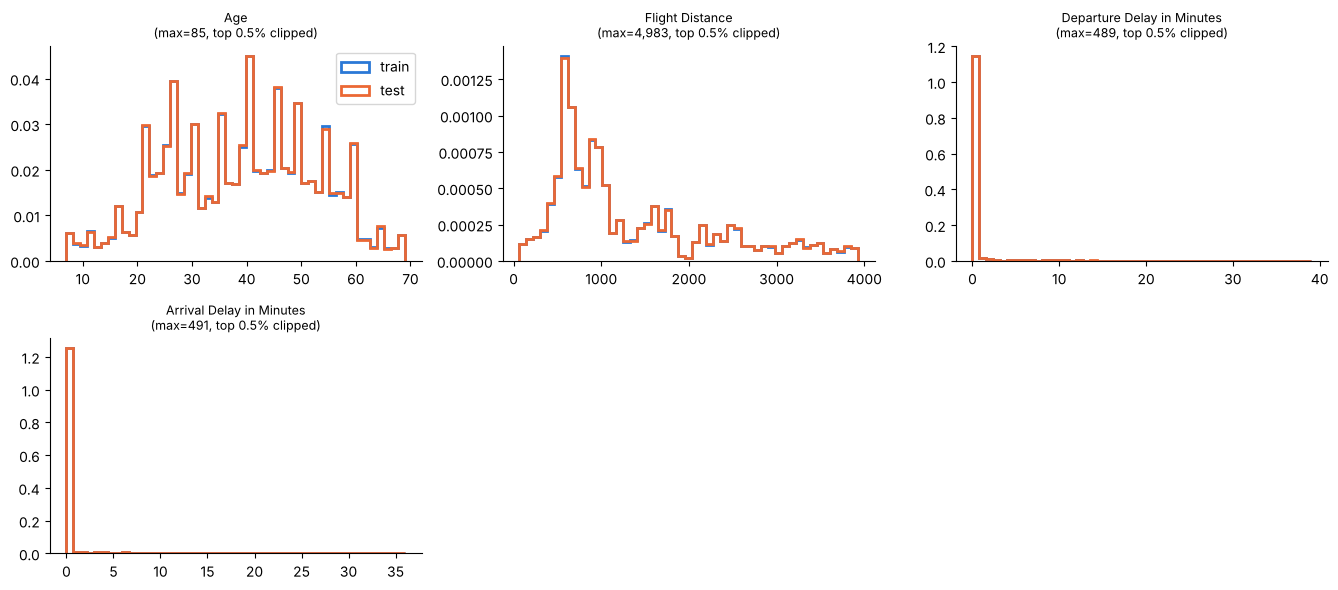

,count,mean,std,min,25%,50%,75%,max
Age,699635.0,39.001928,13.800943,7.0,27.0,40.0,50.0,85.0
Flight Distance,699635.0,1353.778702,954.422566,67.0,631.0,954.0,1814.0,4983.0
Departure Delay in Minutes,699635.0,1.176209,5.982187,0.0,0.0,0.0,0.0,489.0
Arrival Delay in Minutes,699343.0,1.134280,5.749304,0.0,0.0,0.0,0.0,491.0


In [6]:
n = len(num_cols)
ncol = 3
nrow = int(np.ceil(n / ncol))
fig, axes = plt.subplots(nrow, ncol, figsize=(4.5 * ncol, 3 * nrow), squeeze=False)
for ax, c in zip(axes.flat, num_cols):
    lo, hi = np.nanpercentile(pd.concat([train[c], test[c]]), [0, 99.5])
    bins = np.linspace(lo, hi, 50)
    ax.hist(train[c].dropna(), bins=bins, density=True, histtype="step", lw=2, color=TRAIN_C, label="train")
    ax.hist(test[c].dropna(), bins=bins, density=True, histtype="step", lw=2, color=TEST_C, label="test")
    ax.set_title(f"{c}\n(max={train[c].max():,.0f}, top 0.5% clipped)", fontsize=9)
    ax.spines[["top", "right"]].set_visible(False)
for ax in axes.flat[n:]:
    ax.axis("off")
axes.flat[0].legend()
plt.tight_layout()
plt.savefig(FIG / "q5_numeric_dist.png", dpi=120)
plt.show()

train[num_cols].describe().T

In [7]:
# 図を文字の表にしたもの(区間ごとの割合 %)。train と test を並べる
inf = np.inf
dl = ["0", "1-5", "6-15", "16-30", "31-60", "61-120", "121+"]
de = [0, 1, 6, 16, 31, 61, 121, inf]
bins_spec = {
    "Age": ([0, 10, 20, 30, 40, 50, 60, 70, 80, inf],
            ["<10", "10-19", "20-29", "30-39", "40-49", "50-59", "60-69", "70-79", "80+"]),
    "Flight Distance": ([0, 500, 1000, 1500, 2000, 2500, 3000, 3500, 4000, inf],
                        ["<500", "500-999", "1000-1499", "1500-1999", "2000-2499", "2500-2999", "3000-3499", "3500-3999", "4000+"]),
    "Departure Delay in Minutes": (de, dl),
    "Arrival Delay in Minutes": (de, dl),
}
for c, (edges, labels) in bins_spec.items():
    t = pd.cut(train[c], edges, labels=labels, right=False).value_counts(normalize=True).reindex(labels)
    s = pd.cut(test[c], edges, labels=labels, right=False).value_counts(normalize=True).reindex(labels)
    print(f"== {c} ==")
    display(pd.DataFrame({"train(%)": (t * 100).round(2), "test(%)": (s * 100).round(2)}))

# パーセンタイル(train / test)
qs = [0.5, 0.9, 0.99, 0.995, 0.999, 1.0]
display(pd.DataFrame(
    {c: [f"{train[c].quantile(q):.0f} / {test[c].quantile(q):.0f}" for q in qs] for c in num_cols},
    index=["50%", "90%", "99%", "99.5%", "99.9%", "max"],
).T)

== Age ==


,train(%),test(%)
Age,,
<10,1.26,1.26
10-19,5.83,5.81
20-29,22.36,22.34
30-39,20.16,20.23
40-49,25.16,25.25
50-59,19.34,19.24
60-69,5.43,5.44
70-79,0.44,0.43
80+,0.01,0.01


== Flight Distance ==


,train(%),test(%)
Flight Distance,,
<500,9.77,9.82
500-999,43.47,43.46
1000-1499,12.38,12.37
1500-1999,10.88,10.85
2000-2499,8.41,8.42
2500-2999,5.66,5.70
3000-3499,5.64,5.61
3500-3999,3.76,3.74
4000+,0.03,0.03


== Departure Delay in Minutes ==


,train(%),test(%)
Departure Delay in Minutes,,
0,90.78,90.84
1-5,3.69,3.66
6-15,2.87,2.83
16-30,1.71,1.73
31-60,0.90,0.90
61-120,0.02,0.02
121+,0.03,0.02


== Arrival Delay in Minutes ==


,train(%),test(%)
Arrival Delay in Minutes,,
0,91.57,91.57
1-5,2.74,2.74
6-15,3.02,3.06
16-30,1.84,1.82
31-60,0.78,0.77
61-120,0.01,0.02
121+,0.03,0.02


,50%,90%,99%,99.5%,99.9%,max
Age,40 / 40,57 / 57,68 / 68,69 / 69,70 / 70,85 / 85
Flight Distance,954 / 954,2933 / 2928,3873 / 3868,3929 / 3927,3995 / 3995,4983 / 4983
Departure Delay in Minutes,0 / 0,0 / 0,30 / 30,39 / 38,52 / 52,489 / 480
Arrival Delay in Minutes,0 / 0,0 / 0,28 / 28,36 / 36,49 / 49,491 / 471


**見えたこと**(ここに書く)
- 事実:
- 比較:
- 理由の仮説:
- 次の行動:

## Q6. カテゴリ列の分布は? train と test でズレていないか?
なぜ見るか: 少数カテゴリ・test にしかない値の有無と、train/test の比率の差を確認するため。

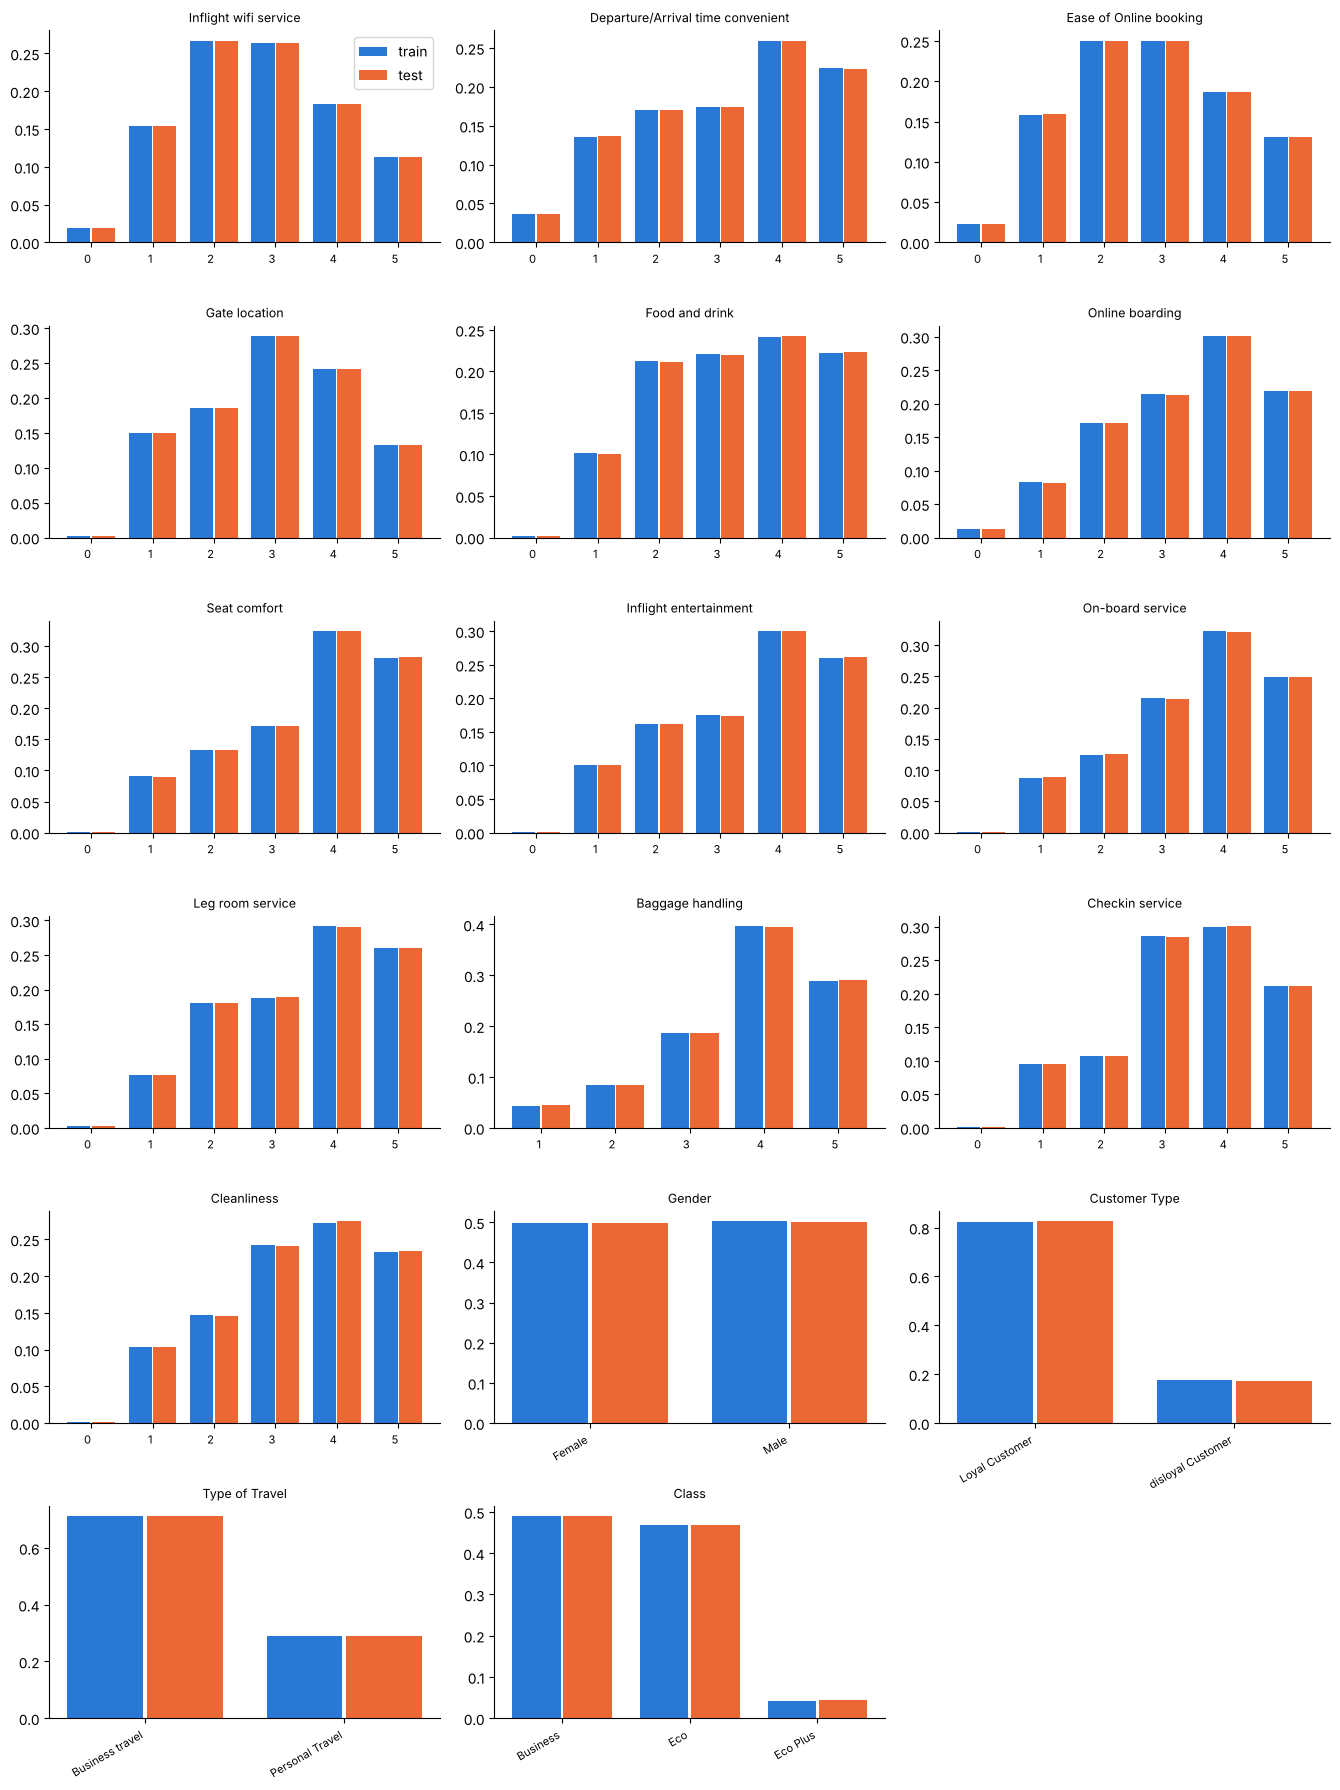

test にだけある値: なし


In [8]:
n = len(cat_cols)
ncol = 3
nrow = int(np.ceil(n / ncol))
fig, axes = plt.subplots(nrow, ncol, figsize=(4.5 * ncol, 3 * nrow), squeeze=False)
for ax, c in zip(axes.flat, cat_cols):
    p = pd.DataFrame({
        "train": train[c].astype(str).value_counts(normalize=True),
        "test": test[c].astype(str).value_counts(normalize=True),
    }).fillna(0).sort_index()
    x = np.arange(len(p))
    ax.bar(x - 0.2, p["train"], width=0.38, color=TRAIN_C, label="train")
    ax.bar(x + 0.2, p["test"], width=0.38, color=TEST_C, label="test")
    ax.set_xticks(x, p.index, rotation=30 if p.index.str.len().max() > 4 else 0, ha="right", fontsize=8)
    ax.set_title(c, fontsize=9)
    ax.spines[["top", "right"]].set_visible(False)
for ax in axes.flat[n:]:
    ax.axis("off")
axes.flat[0].legend()
plt.tight_layout()
plt.savefig(FIG / "q6_category_dist.png", dpi=120)
plt.show()

only_test = {c: sorted(set(test[c].dropna().astype(str)) - set(train[c].dropna().astype(str))) for c in cat_cols}
print("test にだけある値:", {c: v for c, v in only_test.items() if v} or "なし")

**見えたこと**(ここに書く)
- 事実:
- 比較:
- 理由の仮説:
- 次の行動:

## Q7. 各列の分布は、target(True / False)で違うか?
なぜ見るか: target と関係のありそうな列(分布が True と False で離れている列)を見つけて、特徴量やモデルの手がかりにするため。ヒストグラムは割合(density)で、箱ひげ図は中央値・四分位・外れ値で、True と False を比べる。

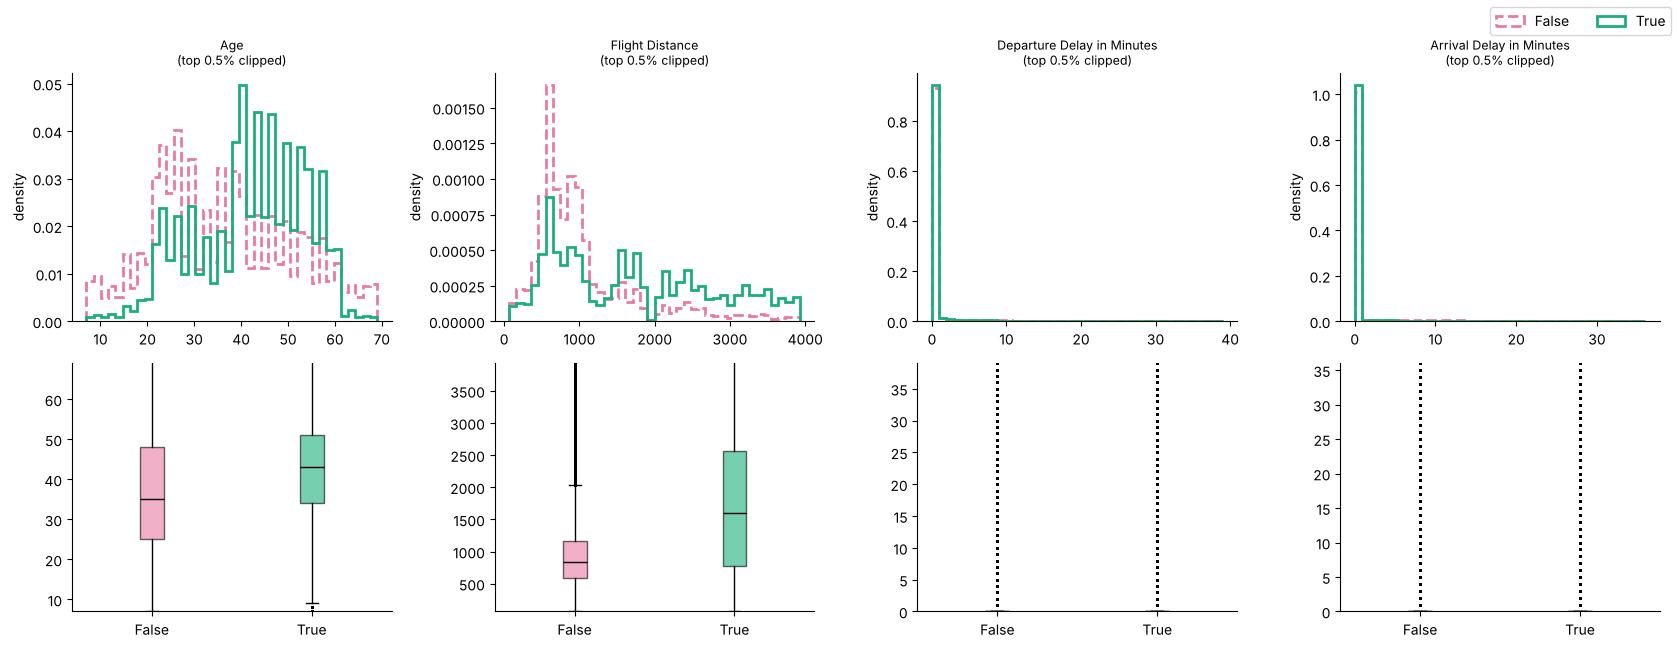

In [9]:
# 連続値の列: 上段=ヒストグラム(割合)、下段=箱ひげ図。False=破線、True=実線
fig, axes = plt.subplots(2, len(num_cols), figsize=(4.2 * len(num_cols), 6.5), squeeze=False)
for j, c in enumerate(num_cols):
    lo, hi = train[c].min(), np.nanpercentile(train[c], 99.5)
    bins = np.linspace(lo, hi, 41)
    for flag, color, ls in [(False, FALSE_C, "--"), (True, TRUE_C, "-")]:
        v = train.loc[train[TARGET] == flag, c].dropna()
        axes[0, j].hist(v, bins=bins, density=True, histtype="step", lw=2, color=color, ls=ls, label=str(flag))
    axes[0, j].set_title(f"{c}\n(top 0.5% clipped)", fontsize=9)
    axes[0, j].set_ylabel("density")
    axes[0, j].spines[["top", "right"]].set_visible(False)

    data = [train.loc[train[TARGET] == flag, c].dropna() for flag in (False, True)]
    bp = axes[1, j].boxplot(data, patch_artist=True, flierprops=dict(marker=".", markersize=2, alpha=0.2),
                            medianprops=dict(color="black"))
    for patch, color in zip(bp["boxes"], (FALSE_C, TRUE_C)):
        patch.set_facecolor(color)
        patch.set_alpha(0.6)
    axes[1, j].set_xticks([1, 2], ["False", "True"])
    axes[1, j].set_ylim(lo, hi)
    axes[1, j].spines[["top", "right"]].set_visible(False)
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper right", ncol=2)  # 凡例は図の外(右上)に置く
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.savefig(FIG / "q7_continuous_by_target.png", dpi=120)
plt.show()

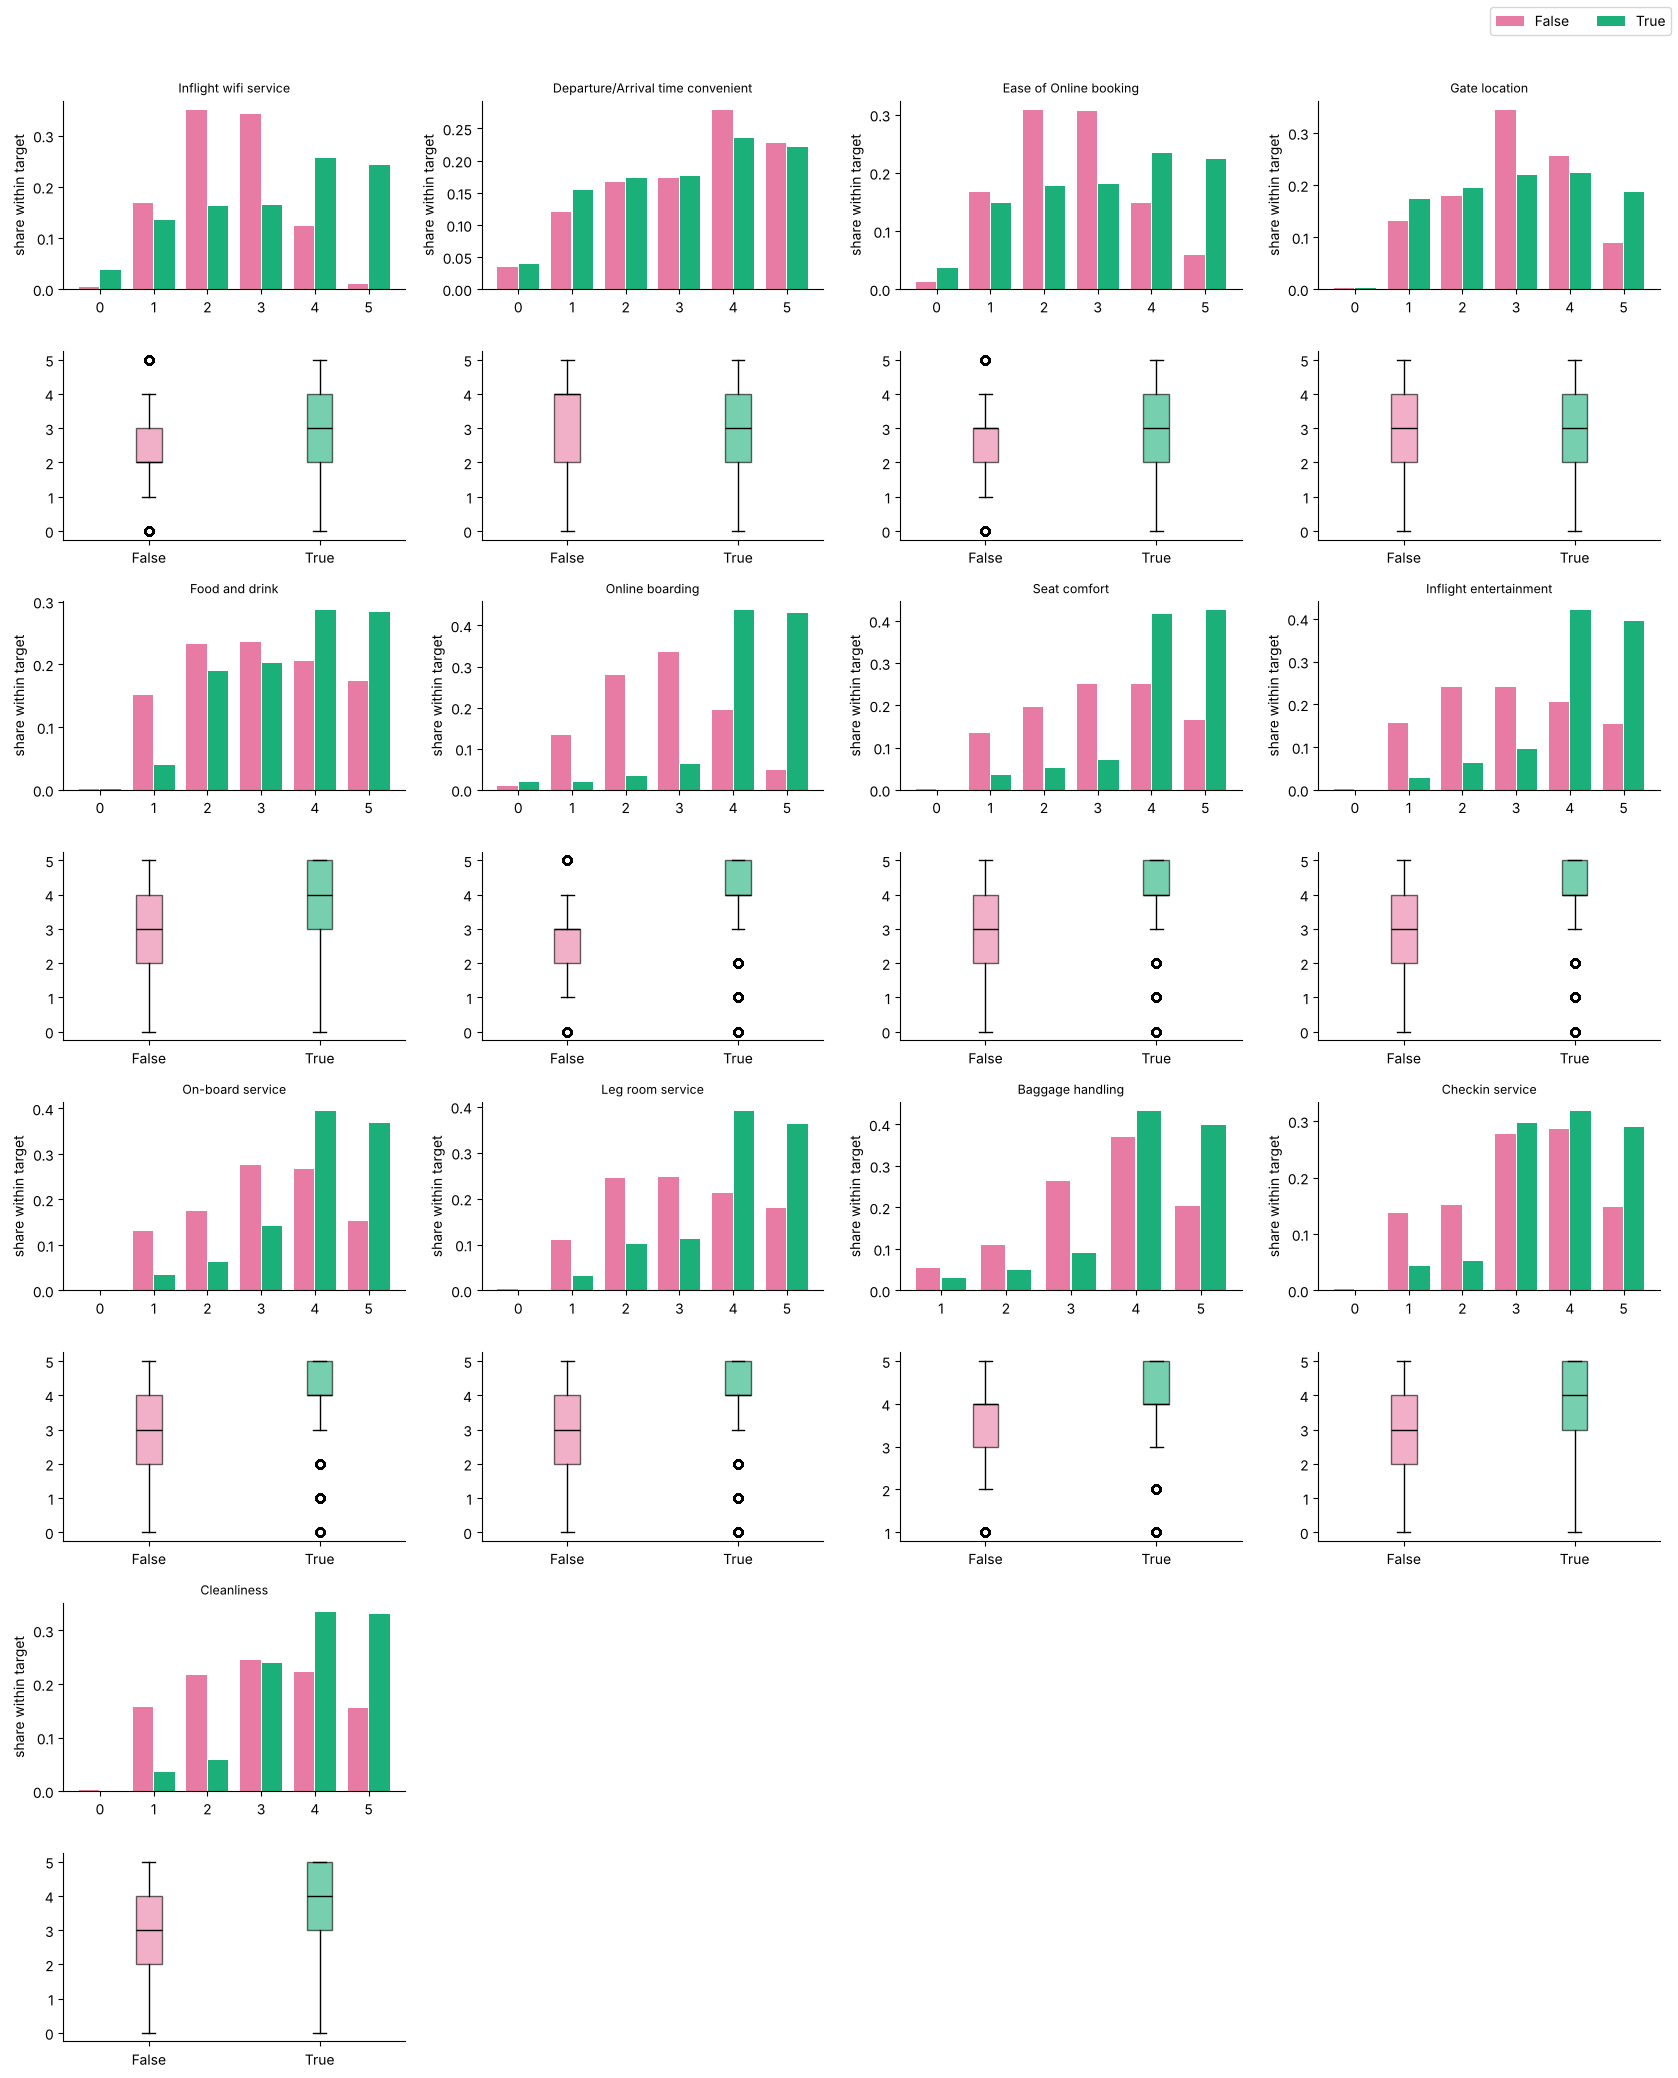

In [10]:
# 評価列(0〜5の整数): 1列ごとに 上=ヒストグラム(割合)、下=箱ひげ図
rate_cols = [c for c in cat_cols if pd.api.types.is_numeric_dtype(train[c])]
ncol = 4
ngrp = int(np.ceil(len(rate_cols) / ncol))
fig, axes = plt.subplots(2 * ngrp, ncol, figsize=(4.2 * ncol, 5.2 * ngrp), squeeze=False)
for k, c in enumerate(rate_cols):
    g, j = divmod(k, ncol)
    ax_h, ax_b = axes[2 * g, j], axes[2 * g + 1, j]
    levels = np.sort(train[c].unique())
    for off, (flag, color) in zip((-0.2, 0.2), [(False, FALSE_C), (True, TRUE_C)]):
        share = train.loc[train[TARGET] == flag, c].value_counts(normalize=True).reindex(levels).fillna(0)
        ax_h.bar(levels + off, share.values, width=0.38, color=color, label=str(flag))
    ax_h.set_xticks(levels)
    ax_h.set_title(c, fontsize=9)
    ax_h.set_ylabel("share within target")
    ax_h.spines[["top", "right"]].set_visible(False)

    data = [train.loc[train[TARGET] == flag, c] for flag in (False, True)]
    bp = ax_b.boxplot(data, patch_artist=True, medianprops=dict(color="black"))
    for patch, color in zip(bp["boxes"], (FALSE_C, TRUE_C)):
        patch.set_facecolor(color)
        patch.set_alpha(0.6)
    ax_b.set_xticks([1, 2], ["False", "True"])
    ax_b.spines[["top", "right"]].set_visible(False)
for k in range(len(rate_cols), ngrp * ncol):  # 余ったマスは消す
    g, j = divmod(k, ncol)
    axes[2 * g, j].axis("off")
    axes[2 * g + 1, j].axis("off")
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper right", ncol=2)  # 凡例は図の外(右上)に置く
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.savefig(FIG / "q7_ratings_by_target.png", dpi=120)
plt.show()

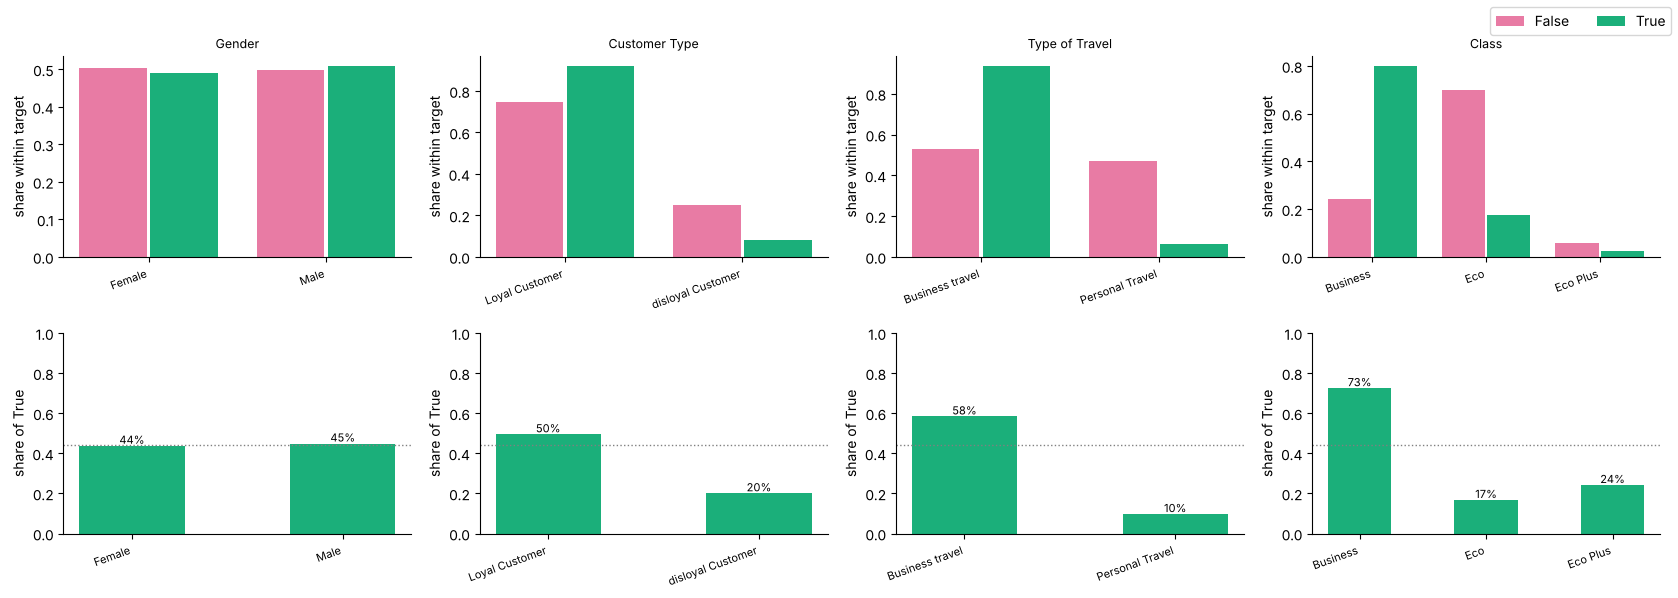

In [11]:
# 文字列の列(カテゴリ): 箱ひげ図は作れないので、上=ヒストグラム相当(割合)、下=カテゴリごとの True の割合
str_cols = [c for c in cat_cols if c not in rate_cols]
fig, axes = plt.subplots(2, len(str_cols), figsize=(4.2 * len(str_cols), 6), squeeze=False)
for j, c in enumerate(str_cols):
    levels = sorted(train[c].unique())
    x = np.arange(len(levels))
    for off, (flag, color) in zip((-0.2, 0.2), [(False, FALSE_C), (True, TRUE_C)]):
        share = train.loc[train[TARGET] == flag, c].value_counts(normalize=True).reindex(levels).fillna(0)
        axes[0, j].bar(x + off, share.values, width=0.38, color=color, label=str(flag))
    axes[0, j].set_xticks(x, levels, rotation=20, ha="right", fontsize=8)
    axes[0, j].set_title(c, fontsize=9)
    axes[0, j].set_ylabel("share within target")
    axes[0, j].spines[["top", "right"]].set_visible(False)

    rate = train.groupby(c)[TARGET].mean().reindex(levels)
    axes[1, j].bar(x, rate.values, width=0.5, color=TRUE_C)
    axes[1, j].axhline(train[TARGET].mean(), color="gray", ls=":", lw=1)  # 全体の True の割合
    for xi, v in zip(x, rate.values):
        axes[1, j].text(xi, v + 0.01, f"{v:.0%}", ha="center", fontsize=8)
    axes[1, j].set_xticks(x, levels, rotation=20, ha="right", fontsize=8)
    axes[1, j].set_ylim(0, 1)
    axes[1, j].set_ylabel("share of True")
    axes[1, j].spines[["top", "right"]].set_visible(False)
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper right", ncol=2)  # 凡例は図の外(右上)に置く
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.savefig(FIG / "q7_categorical_by_target.png", dpi=120)
plt.show()

**見えたこと**(ここに書く)
- 事実:
- 比較:
- 理由の仮説:
- 次の行動:

## まとめ(EDA後に書く)
- `positive` の値: 
- カテゴリ列 / 欠損 / 外れ値で決めたこと:
- 次に試す特徴量: